In [2]:
import numpy as np
import matplotlib.pyplot as plt


## Test for LISA sensitivity at waveform frequencies

In [3]:
# Example frequency array representing output from a waveform model.
waveform_frequencies = np.logspace(
    np.log10(1e-4),
    np.log10(1e-1),
    500,
)

In [4]:
from SensaLISA import LISASensitivityFromWaveform

In [5]:
# Calculate LISA noise at the waveform frequencies.
lisa_waveform = LISASensitivityFromWaveform(
    frequencies=waveform_frequencies,
    observation_time="4yr",
)

frequencies, noise_psd = lisa_waveform.get_psd()
_, noise_asd = lisa_waveform.get_asd()

print("Number of waveform frequencies:", len(frequencies))
print(f"Minimum waveform frequency: {frequencies[0]:.4e} Hz")
print(f"Maximum waveform frequency: {frequencies[-1]:.4e} Hz")

print("\nFirst five waveform frequencies:")
print(frequencies[:5])

print("\nFirst five LISA noise PSD values:")
print(noise_psd[:5])


Number of waveform frequencies: 500
Minimum waveform frequency: 1.0000e-04 Hz
Maximum waveform frequency: 1.0000e-01 Hz

First five waveform frequencies:
[0.0001     0.00010139 0.00010281 0.00010424 0.00010569]

First five LISA noise PSD values:
[2.15102189e-33 1.98505050e-33 1.83205198e-33 1.69100485e-33
 1.56096842e-33]


In [6]:
# Confirm that the class preserves the input frequency array.
assert frequencies.shape == waveform_frequencies.shape
assert np.allclose(frequencies, waveform_frequencies)

# Check the calculated noise.
assert np.all(np.isfinite(noise_psd))
assert np.all(noise_psd > 0)
assert np.allclose(noise_asd, np.sqrt(noise_psd))

print("\nWaveform-frequency sensitivity test passed.")


Waveform-frequency sensitivity test passed.


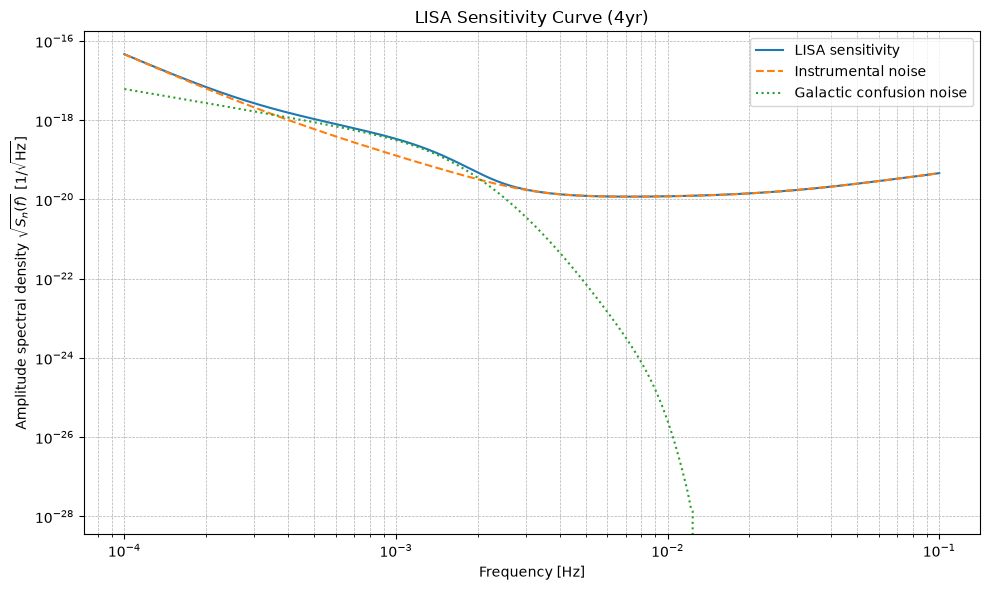

In [7]:
# Plot LISA sensitivity at the waveform frequencies.
lisa_waveform.plot(
    quantity="asd",
    show_components=True,
)

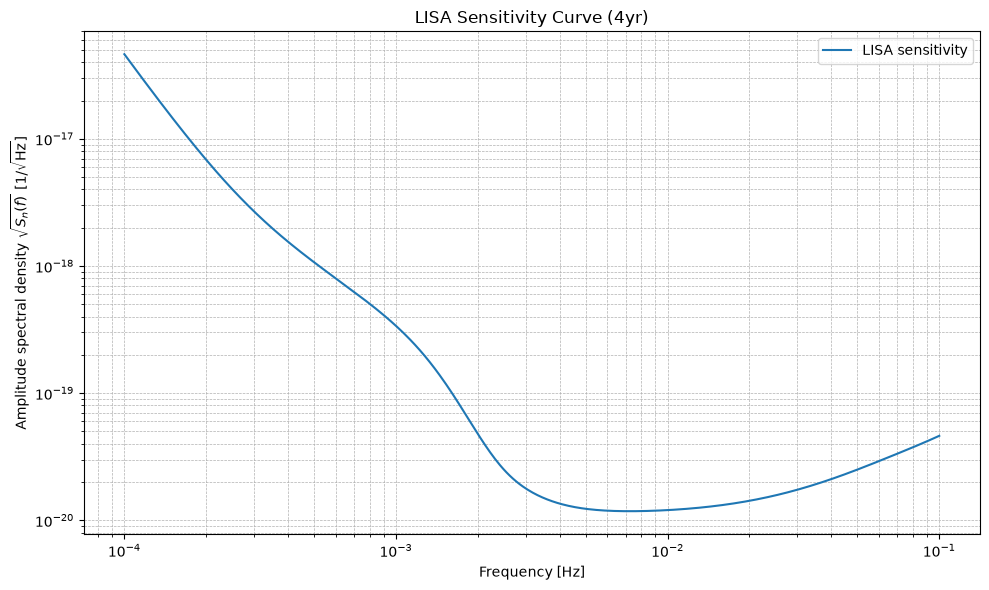

In [8]:
# Plot LISA sensitivity at the waveform frequencies.
lisa_waveform.plot(
    quantity="asd",
)

Figure saved as: lisa_characteristic_strain.png


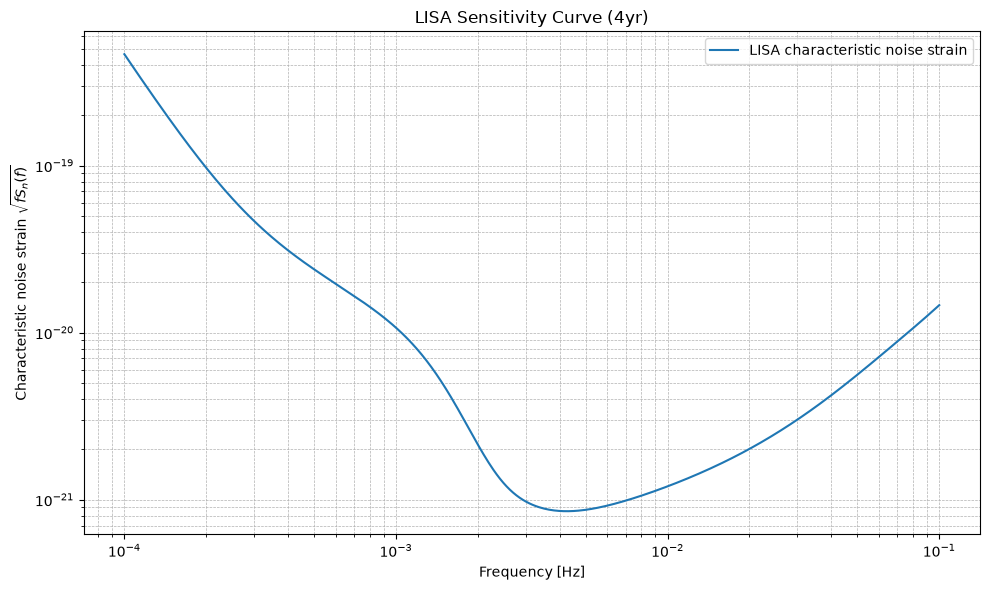

In [10]:
lisa_waveform.plot(
    quantity="characteristic_strain",
    save_fig=True,
    filename="lisa_characteristic_strain.png",
)